**Multiclass Classification**

Impact of AI on Students

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, auc

In [5]:
df = pd.read_csv('/content/ai_student_impact_dataset.csv')
df.head(10)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [7]:
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

In [8]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [9]:
df.shape

(50000, 16)

In [10]:
df.isnull().sum()

,0
Student_ID,0
Major_Category,0
Year_of_Study,0
Pre_Semester_GPA,0
Weekly_GenAI_Hours,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Tool_Diversity,0
Paid_Subscription,0
Traditional_Study_Hours,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['Burnout_Risk_Level'].value_counts()

,count
Burnout_Risk_Level,
Medium,21144
Low,16369
High,12487


In [13]:
df = df.drop('Student_ID' , axis = 1, errors='ignore')
df

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


In [15]:
X = df.drop('Burnout_Risk_Level', axis=1)
y = df['Burnout_Risk_Level']

In [16]:
X

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16
49996,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62
49997,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21
49998,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12


In [17]:
y

,Burnout_Risk_Level
0,High
1,Low
2,Medium
3,Medium
4,Medium
...,...
49995,High
49996,Medium
49997,High
49998,Medium


Displaying descriptive statistics for numerical columns:


,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000



Visualizing distributions of key numerical features:


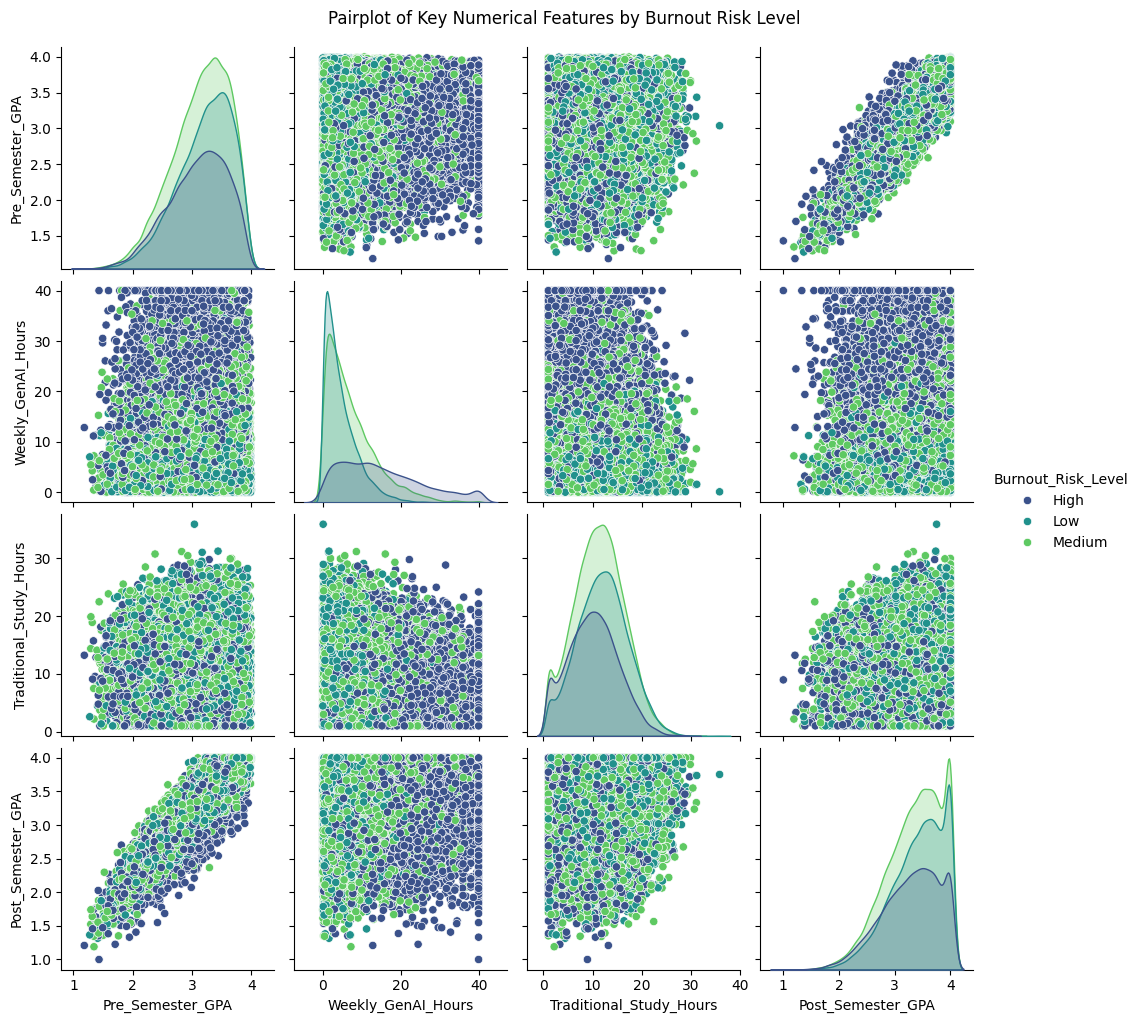


Visualizing the distribution of Major_Category:


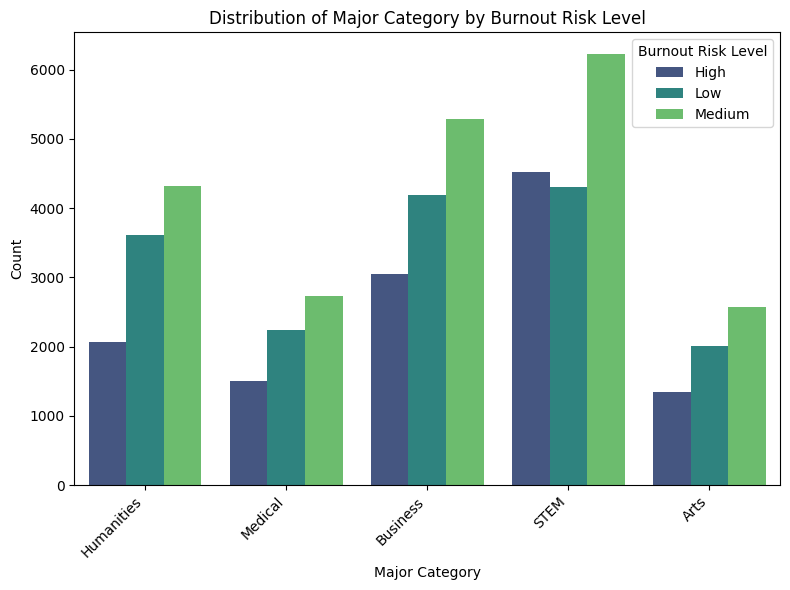

In [18]:
print('Displaying descriptive statistics for numerical columns:')
display(df.describe())

# Visualize distributions of key numerical features
print('\nVisualizing distributions of key numerical features:')
sns.pairplot(df[['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Post_Semester_GPA', 'Burnout_Risk_Level']], hue='Burnout_Risk_Level', palette='viridis')
plt.suptitle('Pairplot of Key Numerical Features by Burnout Risk Level', y=1.02)
plt.show()

# Visualize the distribution of 'Major_Category'
print('\nVisualizing the distribution of Major_Category:')
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Major_Category', hue='Burnout_Risk_Level', palette='viridis')
plt.title('Distribution of Major Category by Burnout Risk Level')
plt.xlabel('Major Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Burnout Risk Level')
plt.tight_layout()
plt.show()


In [19]:
# 'df' has already had 'Student_ID' dropped in an earlier step (cell EAfTNjxjfBQB).
# 'Burnout_Risk_Level' is the target variable.
# To prepare the feature set for one-hot encoding, we create a temporary DataFrame
# by dropping only 'Burnout_Risk_Level' from the current 'df'.
features_for_ohe = df.drop('Burnout_Risk_Level', axis=1)

# Redefine categorical_cols using features_for_ohe to ensure it's available for one-hot encoding.
categorical_cols = features_for_ohe.select_dtypes(include=['object', 'bool']).columns

# Apply one-hot encoding to the identified categorical columns in 'features_for_ohe'.
X_one_hot = pd.get_dummies(features_for_ohe, columns=categorical_cols, drop_first=True)

# Update X to be this new one-hot encoded feature set.
X = X_one_hot

print("X after one-hot encoding:")
display(X.head())

X after one-hot encoding:


,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Major_Category_Business,Major_Category_Humanities,...,Year_of_Study_Sophomore,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Paid_Subscription_True,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban
0,2.418,23.31,1,8.13,5,6,2.393,86.44,False,True,...,False,False,False,False,False,True,False,True,True,False
1,3.821,1.12,5,16.65,3,9,3.696,69.39,False,False,...,False,False,False,True,False,False,False,False,True,False
2,3.398,21.26,2,10.35,5,9,3.499,73.93,True,False,...,False,False,False,False,True,True,False,False,False,True
3,3.789,1.82,4,15.23,2,2,4.000,63.58,True,False,...,False,False,False,False,False,False,True,False,True,False
4,3.635,9.29,4,12.55,4,4,3.798,100.00,False,False,...,True,True,False,False,False,False,False,False,True,False


In [20]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le_burnout = LabelEncoder()

# Apply Label Encoding to the target variable y
y = le_burnout.fit_transform(y)

print("y after label encoding:")
print(y[:5]) # Display first 5 encoded values
print(f"Mapping: {dict(zip(le_burnout.classes_, le_burnout.transform(le_burnout.classes_)))}")

y after label encoding:
[0 1 2 2 2]
Mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [21]:
X = X_one_hot.copy() # Start with the full one-hot encoded feature set

# Define all columns to be dropped to arrive at the desired feature set.
# This list is constructed by identifying features that are less correlated or less important
# based on previous analysis and common feature selection practices.
columns_to_drop = [
    'Major_Category_Arts', # Added to keep only one Major_Category (e.g., Major_Category_Humanities)
    'Major_Category_Business',
    'Major_Category_Medical',
    'Major_Category_STEM',
    'Year_of_Study_Junior',
    'Year_of_Study_Senior',
    'Year_of_Study_Sophomore',
    'Primary_Use_Case_Copywriting/Drafting',
    'Primary_Use_Case_Direct_Answer_Generation',
    'Primary_Use_Case_Ideation',
    'Primary_Use_Case_Summarizing_Reading', # Dropping to keep only one Primary_Use_Case
    'Prompt_Engineering_Skill_Novice',
    'Prompt_Engineering_Skill_Intermediate', # Dropping to keep only one Prompt_Engineering_Skill
    'Institutional_Policy_Strict_Ban'
]

# Drop the specified columns from X
X_refined = X.drop(columns=columns_to_drop, axis=1, errors='ignore')

print(f"Original number of features (X_one_hot): {X_one_hot.shape[1]}")
print(f"Number of features after dropping: {X_refined.shape[1]}")
print("X after dropping columns:")
display(X_refined.head())

# Update X to the new DataFrame with dropped columns
X = X_refined

# IMPORTANT: After modifying X, you must re-run the following steps:
# 1. Train-test split (X_train, X_test, y_train, y_test)
# 2. Feature scaling (StandardScaler)
# 3. Model training and evaluation

Original number of features (X_one_hot): 25
Number of features after dropping: 14
X after dropping columns:


,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Major_Category_Humanities,Year_of_Study_Graduate,Primary_Use_Case_Debugging/Troubleshooting,Prompt_Engineering_Skill_Beginner,Paid_Subscription_True,Institutional_Policy_Allowed_With_Citation
0,2.418,23.31,1,8.13,5,6,2.393,86.44,True,False,False,True,True,True
1,3.821,1.12,5,16.65,3,9,3.696,69.39,False,False,False,False,False,True
2,3.398,21.26,2,10.35,5,9,3.499,73.93,False,False,False,True,False,False
3,3.789,1.82,4,15.23,2,2,4.000,63.58,False,False,False,False,False,True
4,3.635,9.29,4,12.55,4,4,3.798,100.00,False,False,True,False,False,True


In [22]:
X.columns

Index(['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity',
       'Traditional_Study_Hours', 'Perceived_AI_Dependency',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Major_Category_Humanities',
       'Year_of_Study_Graduate', 'Primary_Use_Case_Debugging/Troubleshooting',
       'Prompt_Engineering_Skill_Beginner', 'Paid_Subscription_True',
       'Institutional_Policy_Allowed_With_Citation'],
      dtype='object')

In [23]:
X = np.array(X)
y = np.array(y)

In [24]:
X

array([[2.418, 23.31, 1, ..., True, True, True],
       [3.821, 1.12, 5, ..., False, False, True],
       [3.398, 21.26, 2, ..., True, False, False],
       ...,
       [3.177, 15.87, 5, ..., False, True, True],
       [3.398, 19.91, 5, ..., False, False, True],
       [3.242, 3.3, 1, ..., True, False, True]], dtype=object)

In [25]:
y

array([0, 1, 2, ..., 0, 2, 1])

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((40000, 14), (10000, 14), (40000,), (10000,))

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



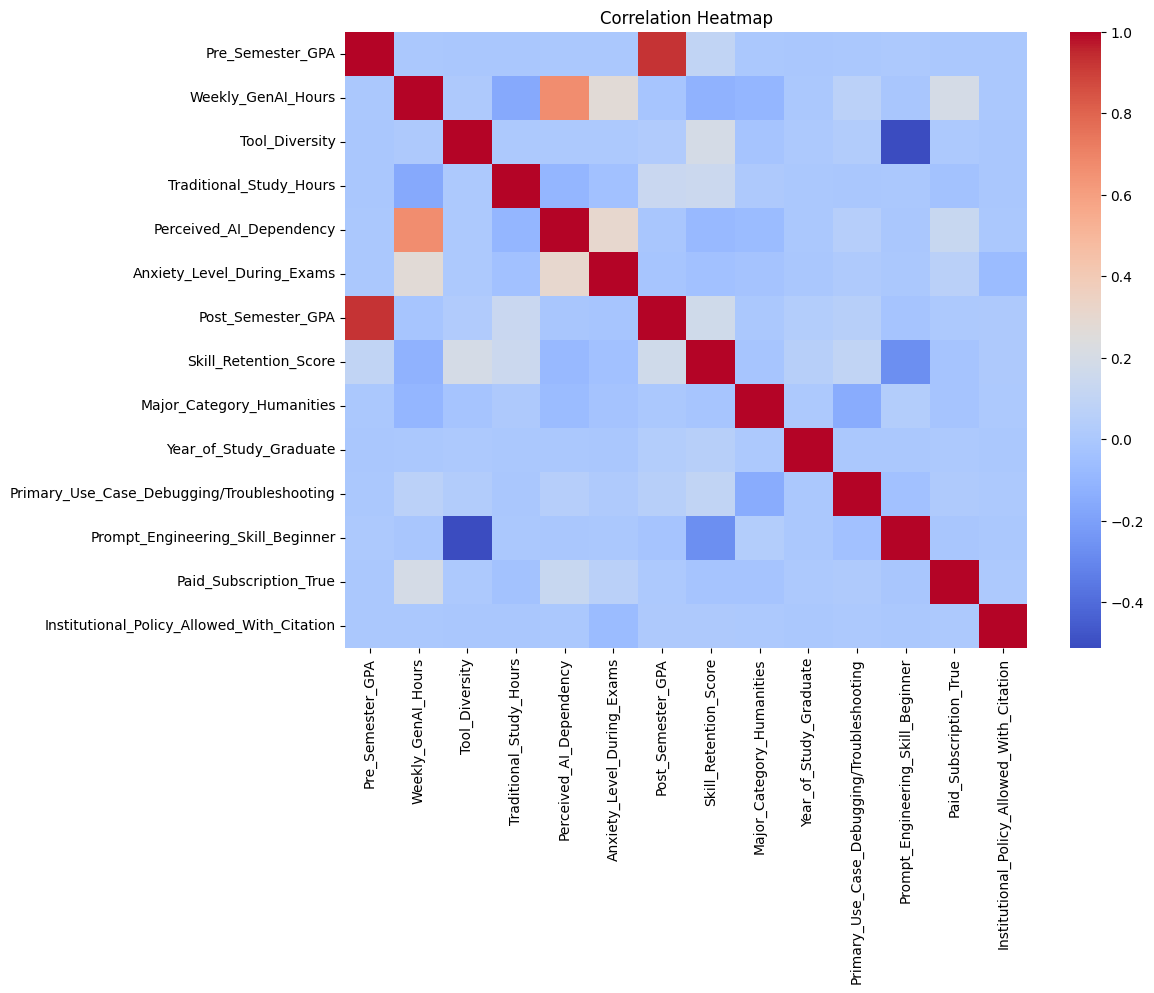

In [29]:
import pandas as pd

# The X variable is currently a NumPy array.
# To convert it back to a DataFrame for correlation, we need to supply the correct column names.
# These are the columns remaining in X_one_hot after ALL previous drops defined in 'filmY1WOy2Cl'.

# Get the column names by applying the 'columns_to_drop' list to the original X_one_hot DataFrame
column_names_for_X = X_one_hot.drop(columns=columns_to_drop, axis=1, errors='ignore').columns

X_df_for_corr = pd.DataFrame(X, columns=column_names_for_X)

correlation_matrix = X_df_for_corr.corr()
plt.figure(figsize=(11, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [71]:
model = LogisticRegression(random_state=42, multi_class='multinomial', solver='lbfgs', )
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(multi_class='multinomial', random_state=42)

In [70]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100,200, 1000],
    'solver': ['newton-cg', 'lbfgs', 'sag', 'saga','sag'],
    'max_iter': [100, 200, 300,400,500,600,900,1000],
    'penalty': ['l2', 'l1', 'elasticnet','l1','l2']# 'l1' and 'elasticnet' require specific solvers and are excluded for simplicity or can be added with conditional logic
}

# Initialize GridSearchCV
grid_search = GridSearchCV(LogisticRegression(multi_class='multinomial', random_state=42),
                           param_grid, cv=5, verbose=1, n_jobs=-1, scoring='accuracy')

# Fit GridSearchCV
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy found: ", grid_search.best_score_)

Fitting 5 folds for each of 1600 candidates, totalling 8000 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
4160 fits failed out of a total of 8000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
640 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_s

Best parameters found:  {'C': 0.1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
Best accuracy found:  0.5320499999999999


In [72]:
y_pred = grid_search.best_estimator_.predict(X_test_scaled)

In [73]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.53


In [74]:
confusion = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(confusion)

Confusion Matrix:
[[1149  234 1153]
 [  87 1646 1536]
 [ 439 1214 2542]]


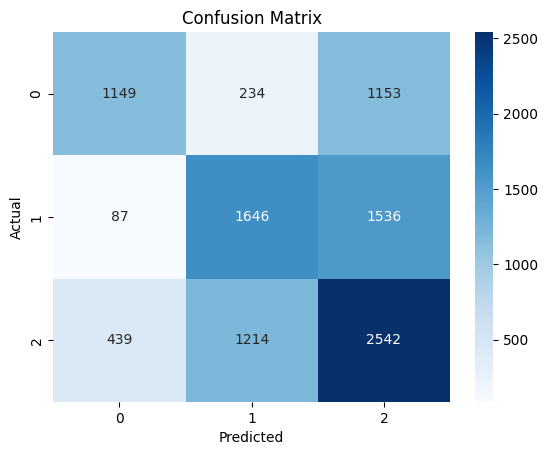

In [75]:
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [76]:
classification_rep = classification_report(y_test, y_pred)
print('Classification Report:')
print(classification_rep)

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.45      0.55      2536
           1       0.53      0.50      0.52      3269
           2       0.49      0.61      0.54      4195

    accuracy                           0.53     10000
   macro avg       0.57      0.52      0.53     10000
weighted avg       0.55      0.53      0.53     10000



In [77]:
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob_full = model.predict_proba(X_test)

# Calculate overall ROC AUC using 'ovr' strategy with macro average
# This correctly uses the full probability array and specifies the multi_class strategy.
roc_auc_macro_avg = roc_auc_score(y_test, y_pred_prob_full, multi_class='ovr', average='macro')

# Prepare for plotting individual ROC curves for each class (one-vs-rest)
n_classes = len(np.unique(y_test))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    y_test_binary = (y_test == i).astype(int) # Binarize for current class
    fpr[i], tpr[i], _ = roc_curve(y_test_binary, y_pred_prob_full[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

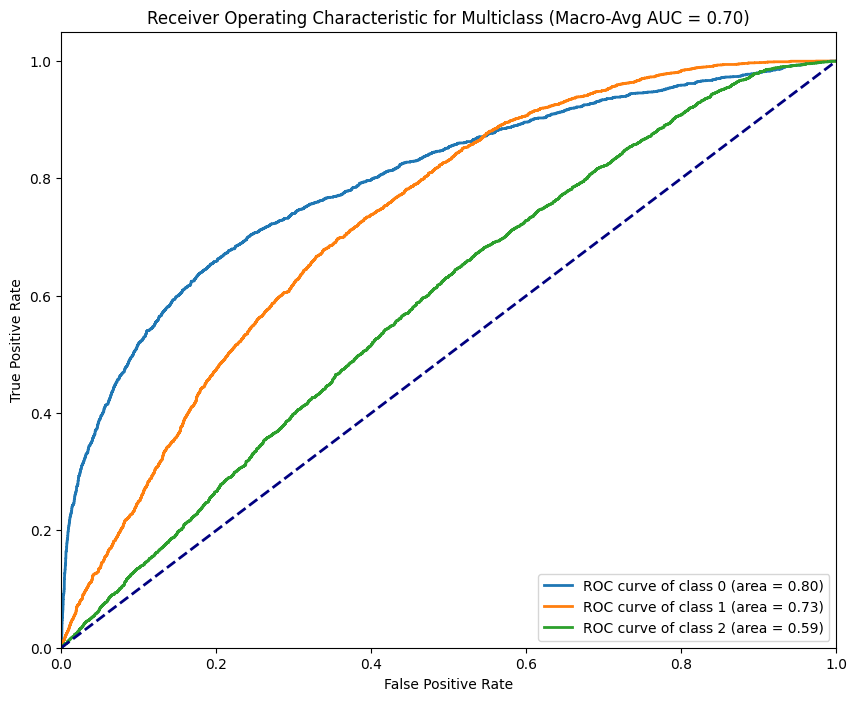

In [78]:
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic for Multiclass (Macro-Avg AUC = {roc_auc_macro_avg:.2f})')
plt.legend(loc='lower right')
plt.show()

**DECISION TREE**

In [79]:
!pip install pydotplus

In [80]:
# pip install graphviz - install using cmd

In [81]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import metrics

In [82]:
clf = DecisionTreeClassifier()

In [83]:
clf.fit(X_train, y_train)


DecisionTreeClassifier()

In [84]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define the parameter grid for DecisionTreeClassifier
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None], # Max depth of the tree
    'min_samples_leaf': [1, 5, 10, 20],
    'min_samples_split': [2, 5, 10, 20],
    'criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}

# Initialize GridSearchCV for Decision Tree
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                               param_grid_dt, cv=5, verbose=1, n_jobs=-1, scoring='accuracy')

# Fit GridSearchCV to the training data
# Decision Trees are generally not sensitive to feature scaling, so X_train is used directly.
grid_search_dt.fit(X_train, y_train)

# Print the best parameters and best score
print("\nBest parameters found for Decision Tree: ", grid_search_dt.best_params_)
print("Best accuracy found for Decision Tree: ", grid_search_dt.best_score_)


Fitting 5 folds for each of 160 candidates, totalling 800 fits

Best parameters found for Decision Tree:  {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best accuracy found for Decision Tree:  0.5204


In [85]:
y_pred = grid_search_dt.best_estimator_.predict(X_test)

In [86]:
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred, average='weighted')
recall = metrics.recall_score(y_test, y_pred, average='weighted')
f1_score = metrics.f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f"Accuracy (Optimized Decision Tree): {accuracy:.2f}")
print(f"Precision (Optimized Decision Tree): {precision:.2f}")
print(f"Recall (Optimized Decision Tree): {recall:.2f}")
print(f"F1 Score (Optimized Decision Tree): {f1_score:.2f}")

Accuracy (Optimized Decision Tree): 0.52
Precision (Optimized Decision Tree): 0.53
Recall (Optimized Decision Tree): 0.52
F1 Score (Optimized Decision Tree): 0.52


In [87]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [88]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [89]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define the parameter grid for RandomForestClassifier
param_grid_rf = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_depth': [5, 10, 15, None], # Maximum depth of the tree
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                               param_grid_rf, cv=5, verbose=1, n_jobs=-1, scoring='accuracy')

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

# Print the best parameters and best score
print("\nBest parameters found for Random Forest: ", grid_search_rf.best_params_)
print("Best accuracy found for Random Forest: ", grid_search_rf.best_score_)

# Make predictions with the best estimator
rf_y_pred_optimized = grid_search_rf.best_estimator_.predict(X_test)

# Evaluate the optimized Random Forest model
rf_accuracy_optimized = accuracy_score(y_test, rf_y_pred_optimized)
rf_precision_optimized = precision_score(y_test, rf_y_pred_optimized, average='weighted')
rf_recall_optimized = recall_score(y_test, rf_y_pred_optimized, average='weighted')
rf_f1_score_optimized = f1_score(y_test, rf_y_pred_optimized, average='weighted')

print("\nOptimized Random Forest Metrics:")
print(f"Accuracy: {rf_accuracy_optimized:.2f}")
print(f"Precision: {rf_precision_optimized:.2f}")
print(f"Recall: {rf_recall_optimized:.2f}")
print(f"F1 Score: {rf_f1_score_optimized:.2f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters found for Random Forest:  {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best accuracy found for Random Forest:  0.52805

Optimized Random Forest Metrics:
Accuracy: 0.53
Precision: 0.55
Recall: 0.53
F1 Score: 0.53


In [90]:
rf_y_pred = grid_search_rf.best_estimator_.predict(X_test)

In [91]:
from sklearn import metrics

rf_accuracy = metrics.accuracy_score(y_test, rf_y_pred)
rf_precision = metrics.precision_score(y_test, rf_y_pred, average='weighted')
rf_recall = metrics.recall_score(y_test, rf_y_pred, average='weighted')
rf_f1_score = metrics.f1_score(y_test, rf_y_pred, average='weighted')

# Print evaluation metrics for Random Forest
print("Random Forest Metrics:")
print(f"Accuracy: {rf_accuracy:.2f}")
print(f"Precision: {rf_precision:.2f}")
print(f"Recall: {rf_recall:.2f}")
print(f"F1 Score: {rf_f1_score:.2f}")

Random Forest Metrics:
Accuracy: 0.53
Precision: 0.55
Recall: 0.53
F1 Score: 0.53


In [92]:
from sklearn.ensemble import GradientBoostingClassifier
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_clf.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [93]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# Define an expanded parameter grid for GradientBoostingClassifier
param_grid_gb = {
    'n_estimators': [150],  # Increased number of boosting stages
    'learning_rate': [0.001, 0.1],  # Wider range for learning rate
    'max_depth': [3, 4],  # More options for tree depth
    'subsample': [0.7],  # Different subsampling fractions
    'min_samples_split': [2], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1] # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV for Gradient Boosting with the expanded grid
grid_search_gb = GridSearchCV(GradientBoostingClassifier(random_state=42),
                               param_grid_gb, cv=5, verbose=2, n_jobs=-1, scoring='accuracy')

# Fit GridSearchCV to the training data
grid_search_gb.fit(X_train_scaled, y_train)

# Print the best parameters and best score
print("\nBest parameters found for Gradient Boosting (Expanded Search): ", grid_search_gb.best_params_)
print("Best accuracy found for Gradient Boosting (Expanded Search): ", grid_search_gb.best_score_)

# Make predictions with the best estimator from the expanded search
gb_y_pred_optimized = grid_search_gb.best_estimator_.predict(X_test_scaled)

# Evaluate the optimized Gradient Boosting model
gb_accuracy_optimized = metrics.accuracy_score(y_test, gb_y_pred_optimized)
gb_precision_optimized = metrics.precision_score(y_test, gb_y_pred_optimized, average='weighted')
gb_recall_optimized = metrics.recall_score(y_test, gb_y_pred_optimized, average='weighted')
gb_f1_score_optimized = metrics.f1_score(y_test, gb_y_pred_optimized, average='weighted')

print("\nOptimized Gradient Boosting Metrics (Expanded Search):")
print(f"Accuracy: {gb_accuracy_optimized:.2f}")
print(f"Precision: {gb_precision_optimized:.2f}")
print(f"Recall: {gb_recall_optimized:.2f}")
print(f"F1 Score: {gb_f1_score_optimized:.2f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best parameters found for Gradient Boosting (Expanded Search):  {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150, 'subsample': 0.7}
Best accuracy found for Gradient Boosting (Expanded Search):  0.5266249999999999

Optimized Gradient Boosting Metrics (Expanded Search):
Accuracy: 0.53
Precision: 0.54
Recall: 0.53
F1 Score: 0.53


In [94]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_clf.fit(X_train_scaled, y_train)
gb_y_pred = gb_clf.predict(X_test_scaled)

In [95]:
import sklearn.metrics as metrics

gb_accuracy = metrics.accuracy_score(y_test, gb_y_pred)
gb_precision = metrics.precision_score(y_test, gb_y_pred, average='weighted')
gb_recall = metrics.recall_score(y_test, gb_y_pred, average='weighted')
gb_f1_score = metrics.f1_score(y_test, gb_y_pred, average='weighted')

# Print evaluation metrics for Gradient Boosting
print("\nGradient Boosting Metrics:")
print(f"Accuracy: {gb_accuracy:.2f}")
print(f"Precision: {gb_precision:.2f}")
print(f"Recall: {gb_recall:.2f}")
print(f"F1 Score: {gb_f1_score:.2f}")


Gradient Boosting Metrics:
Accuracy: 0.53
Precision: 0.54
Recall: 0.53
F1 Score: 0.53


In [96]:
tree1 = DecisionTreeClassifier(random_state=42)
tree1.fit(X_train, y_train)

tree2 = DecisionTreeClassifier(random_state=42, max_depth=3)  # Limited depth for the second tree
tree2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [97]:
tree1_y_pred = tree1.predict(X_test)
tree2_y_pred = tree2.predict(X_test)

In [98]:
tree1_accuracy = metrics.accuracy_score(y_test, tree1_y_pred)
tree1_precision = metrics.precision_score(y_test, tree1_y_pred, average='weighted')
tree1_recall = metrics.recall_score(y_test, tree1_y_pred, average='weighted')
tree1_f1_score = metrics.f1_score(y_test, tree1_y_pred, average='weighted')

In [99]:
tree2_accuracy = metrics.accuracy_score(y_test, tree2_y_pred)
tree2_precision = metrics.precision_score(y_test, tree2_y_pred, average='weighted')
tree2_recall = metrics.recall_score(y_test, tree2_y_pred, average='weighted')
tree2_f1_score = metrics.f1_score(y_test, tree2_y_pred, average='weighted')

In [100]:
print("Decision Tree 1 Metrics:")
print(f"Accuracy: {tree1_accuracy:.2f}")
print(f"Precision: {tree1_precision:.2f}")
print(f"Recall: {tree1_recall:.2f}")
print(f"F1 Score: {tree1_f1_score:.2f}")

print("\nDecision Tree 2 Metrics:")
print(f"Accuracy: {tree2_accuracy:.2f}")
print(f"Precision: {tree2_precision:.2f}")
print(f"Recall: {tree2_recall:.2f}")
print(f"F1 Score: {tree2_f1_score:.2f}")

Decision Tree 1 Metrics:
Accuracy: 0.44
Precision: 0.44
Recall: 0.44
F1 Score: 0.44

Decision Tree 2 Metrics:
Accuracy: 0.51
Precision: 0.53
Recall: 0.51
F1 Score: 0.51


**Support Vector Machine**

In [ ]:
#from sklearn.svm import SVC
#from sklearn.metrics import accuracy_score, classification_report
#from sklearn.inspection import DecisionBoundaryDisplay


In [ ]:
#svm = SVC(kernel='linear', C=1.0)
#svm.fit(X_train_scaled, y_train)

SVC(kernel='linear')

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for SVC
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Initialize GridSearchCV for SVM
grid_search_svm = GridSearchCV(SVC(random_state=42),
                               param_grid_svm, cv=5, verbose=2, n_jobs=-1, scoring='accuracy')

# Fit GridSearchCV to the scaled training data
grid_search_svm.fit(X_train_scaled, y_train)

# Print the best parameters and best score
print("\nBest parameters found for SVM: ", grid_search_svm.best_params_)
print("Best accuracy found for SVM: ", grid_search_svm.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [ ]:
y_pred = svm.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 53.01%

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.41      0.52      2536
           1       0.53      0.51      0.52      3269
           2       0.48      0.62      0.54      4195

    accuracy                           0.53     10000
   macro avg       0.58      0.51      0.53     10000
weighted avg       0.56      0.53      0.53     10000



**K NEAREST NEIGHBORS**

In [101]:
from sklearn.neighbors import KNeighborsClassifier

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best parameters found for KNN:  {'metric': 'manhattan', 'n_neighbors': 61, 'weights': 'distance'}
Best accuracy found for KNN (cross-validation):  0.50555

Optimized KNN Test Accuracy:  0.4998

Optimized KNN Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.36      0.48      2536
           1       0.48      0.46      0.47      3269
           2       0.46      0.61      0.53      4195

    accuracy                           0.50     10000
   macro avg       0.55      0.48      0.49     10000
weighted avg       0.53      0.50      0.50     10000



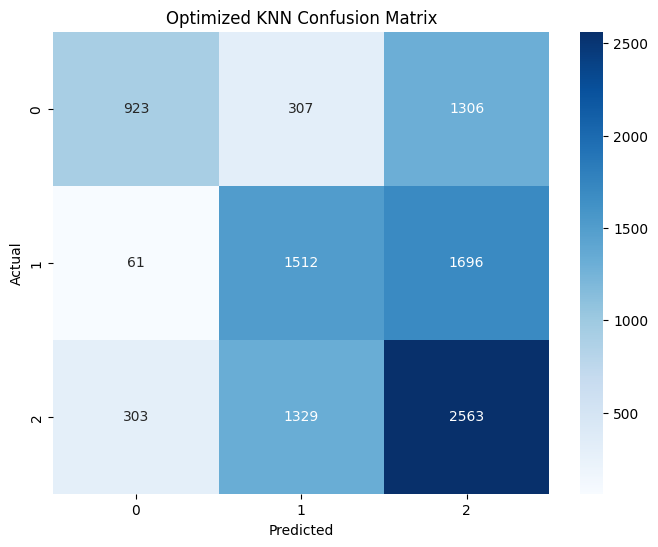

In [102]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define the parameter grid for KNeighborsClassifier
param_grid_knn = {
    'n_neighbors': [3,5,61],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Initialize GridSearchCV for KNN
grid_search_knn = GridSearchCV(KNeighborsClassifier(),
                               param_grid_knn, cv=5, verbose=1, n_jobs=-1, scoring='accuracy')

# Fit GridSearchCV to the scaled training data
grid_search_knn.fit(X_train_scaled, y_train)

# Print the best parameters and best score
print("\nBest parameters found for KNN: ", grid_search_knn.best_params_)
print("Best accuracy found for KNN (cross-validation): ", grid_search_knn.best_score_)

# Make predictions with the best estimator
y_pred_knn_optimized = grid_search_knn.best_estimator_.predict(X_test_scaled)

# Evaluate the optimized KNN model
knn_accuracy_optimized = accuracy_score(y_test, y_pred_knn_optimized)
knn_classification_report = classification_report(y_test, y_pred_knn_optimized)
knn_confusion_matrix = confusion_matrix(y_test, y_pred_knn_optimized)

print("\nOptimized KNN Test Accuracy: ", knn_accuracy_optimized)
print("\nOptimized KNN Classification Report:\n", knn_classification_report)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(knn_confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Optimized KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [103]:
print("Evaluating the best KNN Model from Grid Search...")
# Use the best estimator found by GridSearchCV
knn_best_estimator = grid_search_knn.best_estimator_

y_pred = knn_best_estimator.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Evaluating the best KNN Model from Grid Search...
Model Accuracy: 49.98%

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.36      0.48      2536
           1       0.48      0.46      0.47      3269
           2       0.46      0.61      0.53      4195

    accuracy                           0.50     10000
   macro avg       0.55      0.48      0.49     10000
weighted avg       0.53      0.50      0.50     10000



**ANN**


In [30]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.utils import to_categorical

In [31]:
model = keras.Sequential([

    # Flatten the 28x28 images to a 1D array
    keras.Input(shape=(X_train_scaled.shape[1],)),

    # Fully connected layer with 128 neurons and ReLU activation
    keras.layers.Dense(128, activation='relu'),

    # Dropout layer to prevent overfitting
    keras.layers.Dropout(0.2),

    # Output layer with 10 neurons (for 0-9 digits) and softmax activation
    keras.layers.Dense(10, activation='softmax')
])

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,210 (12.54 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Cross-entropy loss for classification
    metrics=['accuracy']
    )

In [34]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

In [35]:
keras_model = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)), # Use X_train_scaled for input shape
    keras.layers.Dense(512),
    keras.layers.BatchNormalization(), # Add BatchNormalization
    keras.layers.Activation('relu'),   # Add Activation layer after BN
    keras.layers.Dropout(0.3),
    keras.layers.Dense(256),
    keras.layers.BatchNormalization(), # Add BatchNormalization
    keras.layers.Activation('relu'),   # Add Activation layer after BN
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128),
    keras.layers.BatchNormalization(), # Add BatchNormalization
    keras.layers.Activation('relu'),   # Add Activation layer after BN
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(3, activation='softmax')

])

In [36]:
keras_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # Changed loss for multiclass

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Instantiate LabelEncoder
le = LabelEncoder()

# Fit and transform y_train to numerical labels
# This will encode 'High', 'Low', 'Medium' into 0, 1, 2
y_train_numerical = le.fit_transform(y_train)

# Split the scaled training features and the numerically encoded training labels
X_train_nn, X_val, y_train_nn, y_val = train_test_split(X_train_scaled, y_train_numerical, test_size=0.2, random_state=42)

history = keras_model.fit(X_train_nn, y_train_nn, epochs=100, batch_size=10, validation_data=(X_val, y_val), verbose=1)

Epoch 1/100
3200/3200 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.4682 - loss: 1.0113 - val_accuracy: 0.5215 - val_loss: 0.9334
Epoch 2/100
3200/3200 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - accuracy: 0.4952 - loss: 0.9747 - val_accuracy: 0.5194 - val_loss: 0.9322
Epoch 3/100
3200/3200 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.4938 - loss: 0.9690 - val_accuracy: 0.5268 - val_loss: 0.9290
Epoch 4/100
3200/3200 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - accuracy: 0.4969 - loss: 0.9693 - val_accuracy: 0.5288 - val_loss: 0.9276
Epoch 5/100
3200/3200 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - accuracy: 0.4990 - loss: 0.9650 - val_accuracy: 0.5271 - val_loss: 0.9284
Epoch 6/100
3200/3200 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - accuracy: 0.4974 - loss: 0.9659 - val_accuracy: 0.5296 - val_loss: 0.9299
Epoch 7/100
3200/3200 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - accuracy: 0.4999 - loss: 0.9634 - val_accuracy: 0.5270 - val_loss: 0.9316
Epoch 8/100
3200/3200 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - accuracy: 0.4967 -

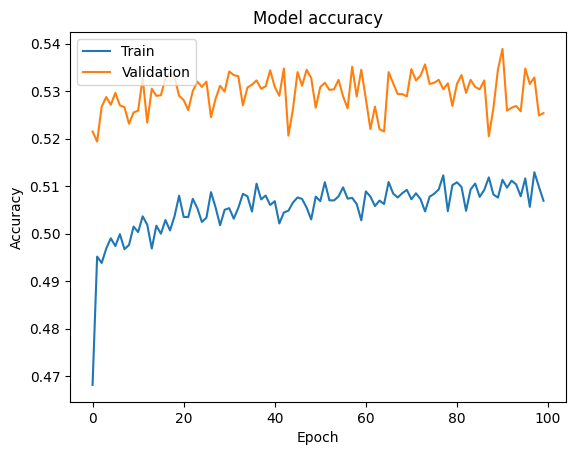

In [38]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

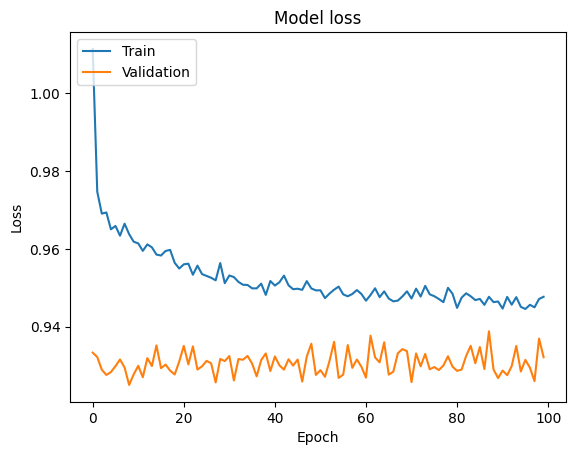

In [39]:
# Plot training loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [40]:
# y_test needs to be numerically encoded using the same LabelEncoder as y_train_numerical.
# The 'le' object was fitted in cell '6AloSBM-lmIQ'.

y_test_numerical = le.transform(y_test)

predictions_ann = keras_model.predict(X_test_scaled)
predicted_labels_ann = np.argmax(predictions_ann, axis=1)

print("Keras ANN Accuracy:", accuracy_score(y_test_numerical, predicted_labels_ann))
print("Keras ANN Classification Report:\n", classification_report(y_test_numerical, predicted_labels_ann))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Keras ANN Accuracy: 0.5233
Keras ANN Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.39      0.51      2536
           1       0.57      0.31      0.40      3269
           2       0.47      0.77      0.58      4195

    accuracy                           0.52     10000
   macro avg       0.59      0.49      0.50     10000
weighted avg       0.57      0.52      0.51     10000



In [41]:
keras_model.save('keras_model.h5')
print("Keras model saved successfully as 'keras_model.h5'")

Keras model saved successfully as 'keras_model.h5'
